<a href="https://www.kaggle.com/code/janmartins/customer-personality-analysis?scriptVersionId=246168947" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Objetivo:
* Usar agrupamento para resumir os segmentos dos clientes

## Foi feito:
Ao longo do notebook, vamos tratar os dados, apresentando gráficos com informações relevantes sobre os clientes, para que seja aplicada técnicas de agrupamento nos livramos dos rótulos e usamos o método do cotovelo para encontrar a quantidade naturais de clusters, apresentamos algumas métricas sobre os clusters e suas divisões e depois tratamos os dados, removendo outliers e algumas colunas com baixa correlação e apresentamos novamente as métricas.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings('ignore')

/kaggle/input/customer-personality-analysis/marketing_campaign.csv


In [2]:
data = pd.read_csv("/kaggle/input/customer-personality-analysis/marketing_campaign.csv", delimiter="\t")

In [3]:
pd.set_option("display.max_columns", None)

# EDA

In [4]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [5]:
data.shape

(2240, 29)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
data['age'] = 2023 - data['Year_Birth']

In [8]:
data.drop(columns=["ID", "Year_Birth"], inplace=True)

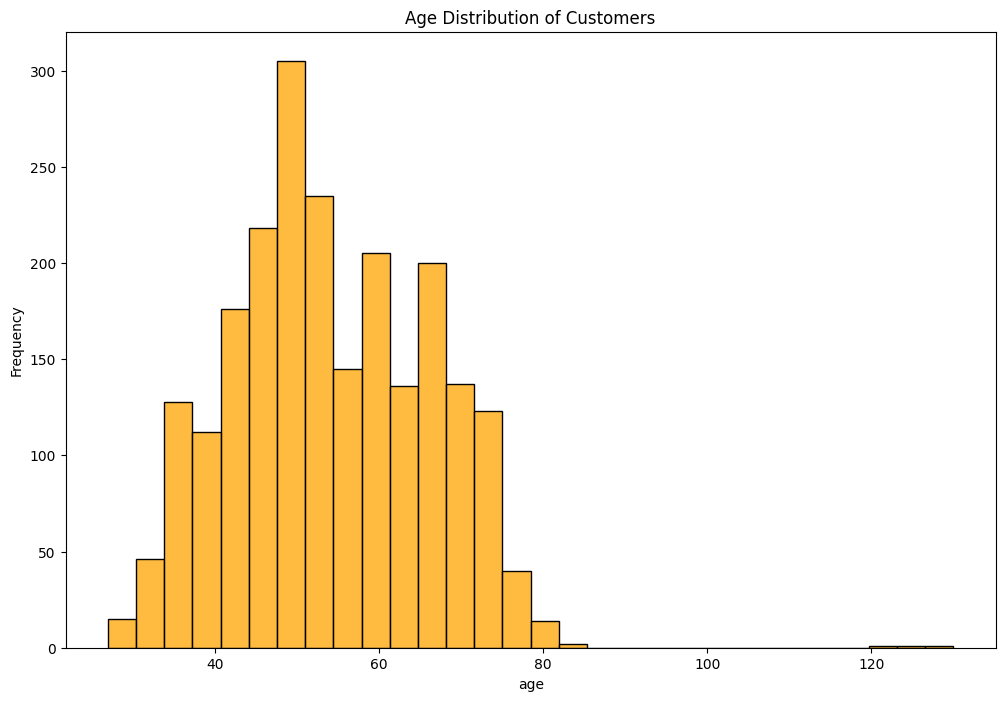

In [9]:
plt.figure(figsize=(12,8))
sns.histplot(data["age"], bins=30, color="orange")
plt.xlabel("age")
plt.ylabel("Frequency")
plt.title("Age Distribution of Customers")
plt.show()

In [10]:
data['age'].value_counts()

age
47     89
52     87
48     83
51     79
45     77
53     77
50     74
58     74
54     71
49     69
67     55
65     53
44     53
71     52
46     52
55     51
64     51
57     50
69     50
68     49
63     49
41     45
60     45
56     44
61     44
66     43
72     43
40     42
37     42
59     42
43     39
42     39
39     38
62     36
70     35
38     32
34     30
74     30
73     29
35     29
36     27
75     21
33     18
77     16
76     16
32     15
31     13
78      8
80      7
79      7
30      5
28      5
29      3
27      2
124     1
82      1
130     1
123     1
83      1
Name: count, dtype: int64

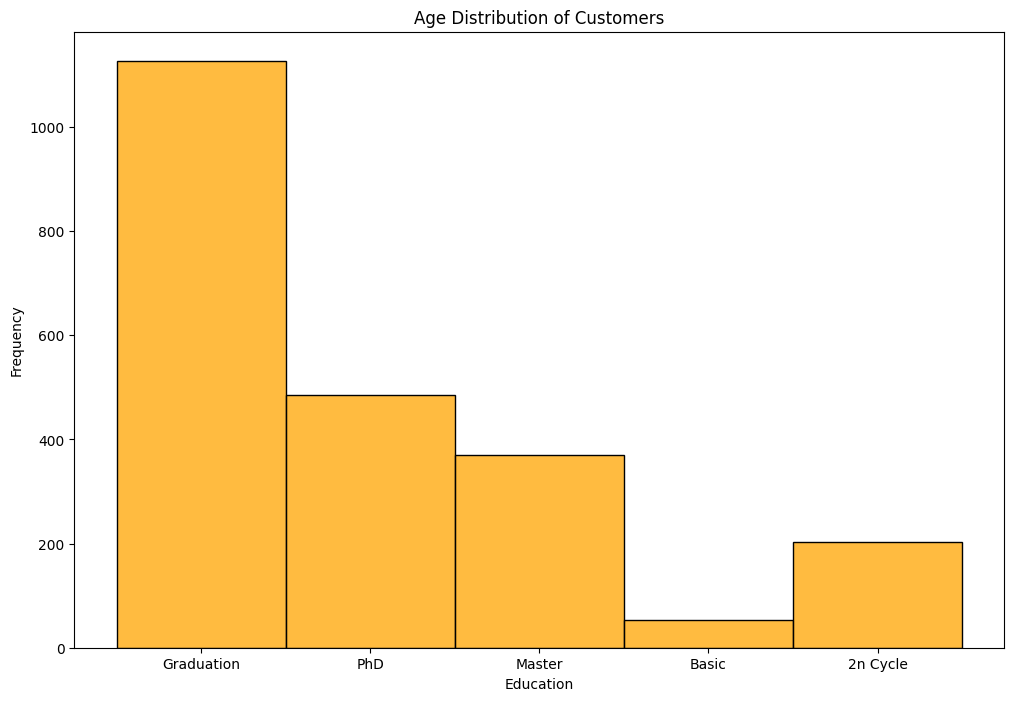

In [11]:
plt.figure(figsize=(12,8))
sns.histplot(data["Education"], bins=30, color="orange")
plt.xlabel("Education")
plt.ylabel("Frequency")
plt.title("Age Distribution of Customers")
plt.show()

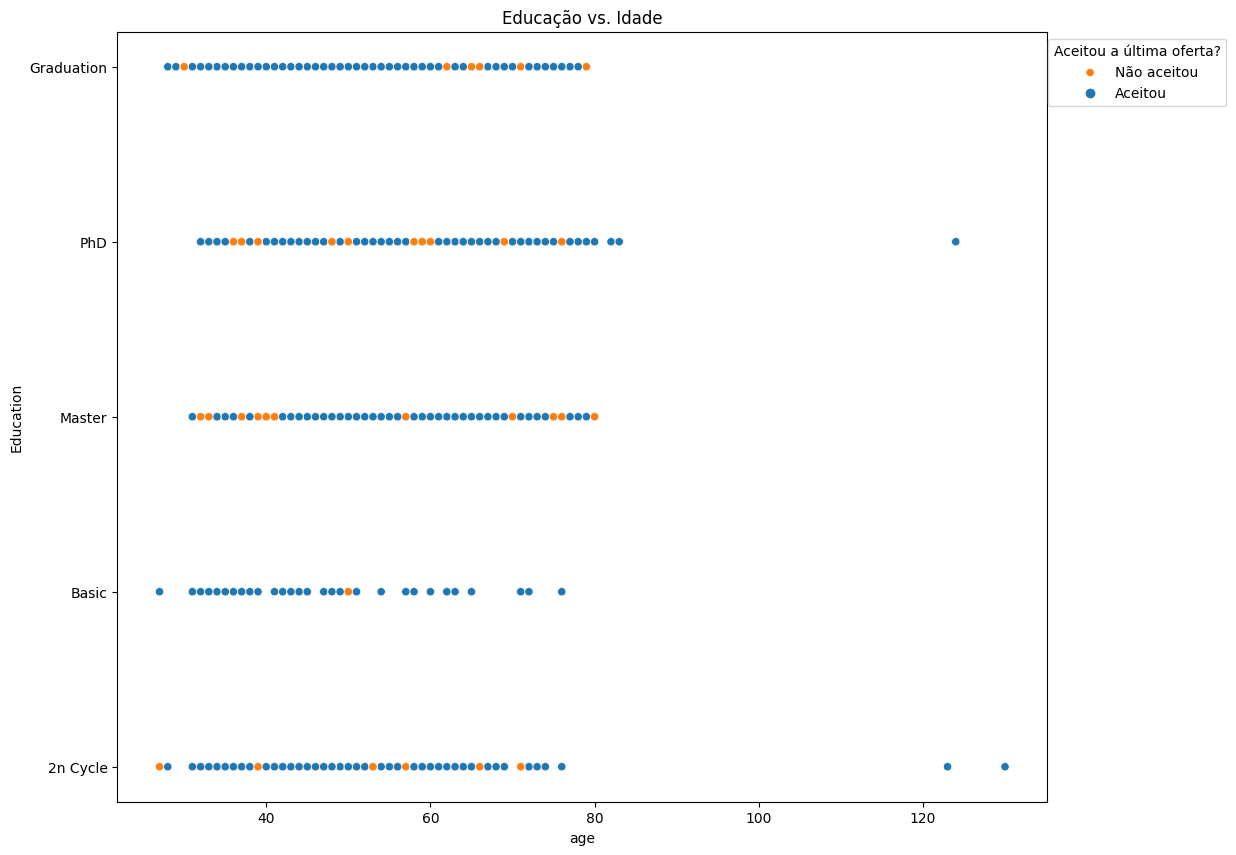

In [12]:
# Vamos ver um pouco mais sobre a dispersão dos dados
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=data,
    x='age',
    y='Education',
    hue='Response',         
)

plt.title('Educação vs. Idade')
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.2, 1.0),
    title='Aceitou a última oferta?',
    labels=['Não aceitou', 'Aceitou']
)
plt.show()

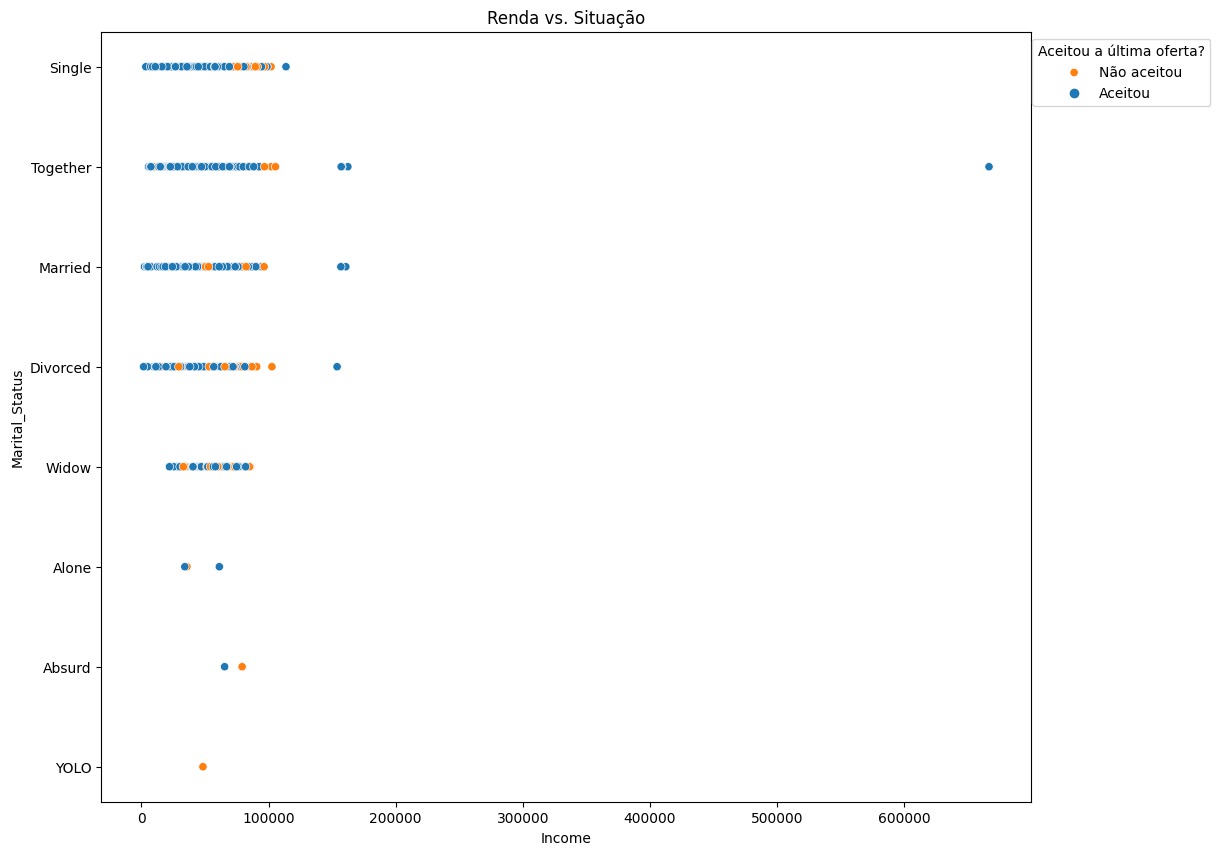

In [13]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=data,
    x='Income',
    y='Marital_Status',
    hue='Response',         
)

plt.title('Renda vs. Situação')
plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.2, 1.0),
    title='Aceitou a última oferta?',
    labels=['Não aceitou', 'Aceitou']
)
plt.show()

In [14]:
data = data.select_dtypes(include=['number'])

In [15]:
data.drop(columns=["Z_Revenue", "Z_CostContact"], inplace=True)

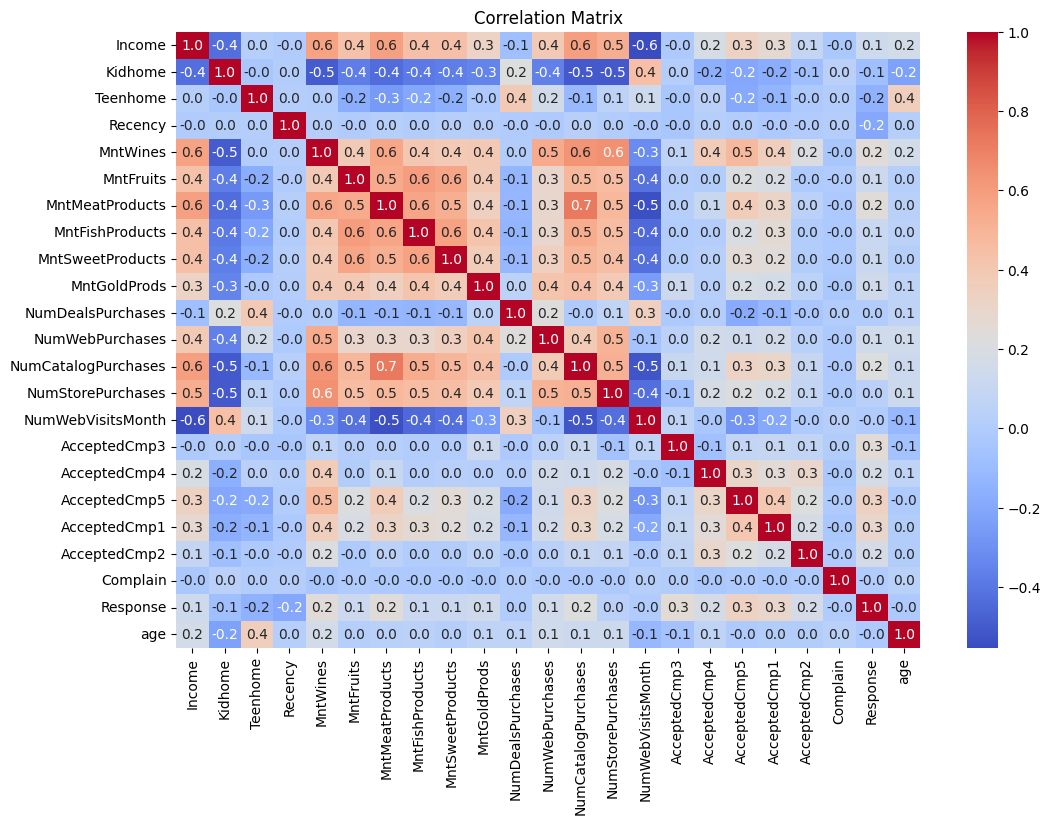

In [16]:
plt.figure(figsize=(12, 8))                     # Define o tamanho da figura
sns.heatmap(                                   # Cria o heatmap
    data.corr(),                               # Matriz de correlação entre as colunas numéricas
    annot=True,                                # Mostra os valores nas células
    cmap="coolwarm",                           # Define o esquema de cores
    fmt=".1f"                                  # Formato dos números (duas casas decimais)
)
plt.title("Correlation Matrix") 
plt.show() 

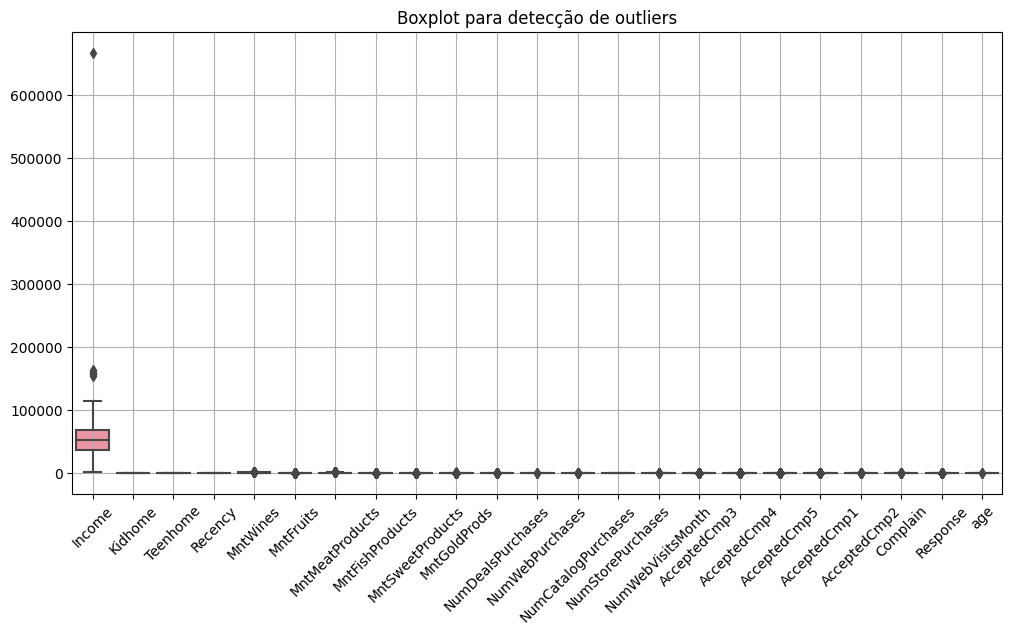

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title('Boxplot para detecção de outliers')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# ML

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

In [19]:
scaler = MinMaxScaler()

In [20]:
normal = scaler.fit_transform(data)

In [21]:
data = pd.DataFrame(
    normal,
    columns=data.columns,
    index=data.index
)

In [22]:
data.shape

(2240, 23)

In [23]:
data.dropna(inplace=True)

In [24]:
data.shape

(2216, 23)

In [25]:
df = data.copy()

In [26]:
data.drop(columns=['Response'], inplace=True)

In [27]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = "auto", random_state = 0)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

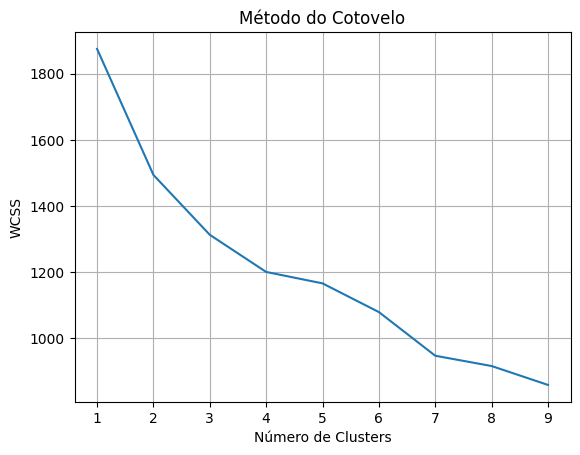

In [28]:
# Método do Cotovelo (Elbow Method) para determinar o número ideal de clusters.
plt.plot(range(1, 10), wcss)
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [29]:
for i in range(2, 10):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = "auto", random_state = 0)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)
    score = silhouette_score(data, kmeans.labels_)
    print(f"Silhouette Score {i} grupos: ",score)

Silhouette Score 2 grupos:  0.23287994036705723
Silhouette Score 3 grupos:  0.21914321892391211
Silhouette Score 4 grupos:  0.1968050352817306
Silhouette Score 5 grupos:  0.180182965403937
Silhouette Score 6 grupos:  0.19778273119934917
Silhouette Score 7 grupos:  0.1889754630523098
Silhouette Score 8 grupos:  0.17384575869656227
Silhouette Score 9 grupos:  0.18479297852721668


In [30]:
k = 2

# Aplicando o KMeans com todas as colunas e o número ideal de clusters
kmeans = KMeans(n_clusters = k, init = 'k-means++', n_init = "auto", random_state = 0)
y_kmeans = kmeans.fit_predict(data)

In [31]:
# Apesar de usarmos o k ideal, temos dificuldades em usar todos os dados para fazer os clusters, vamos tentar eliminar algumas features.
ari_kmeans = adjusted_rand_score(df['Response'], kmeans.labels_)
print(f"Adjusted Rand Index (K-Means): {ari_kmeans}")

Adjusted Rand Index (K-Means): 0.035496308704117484


In [32]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

outliers_mask = (data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))

In [33]:
filter = ~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)
data = data[filter]
df = df[filter]

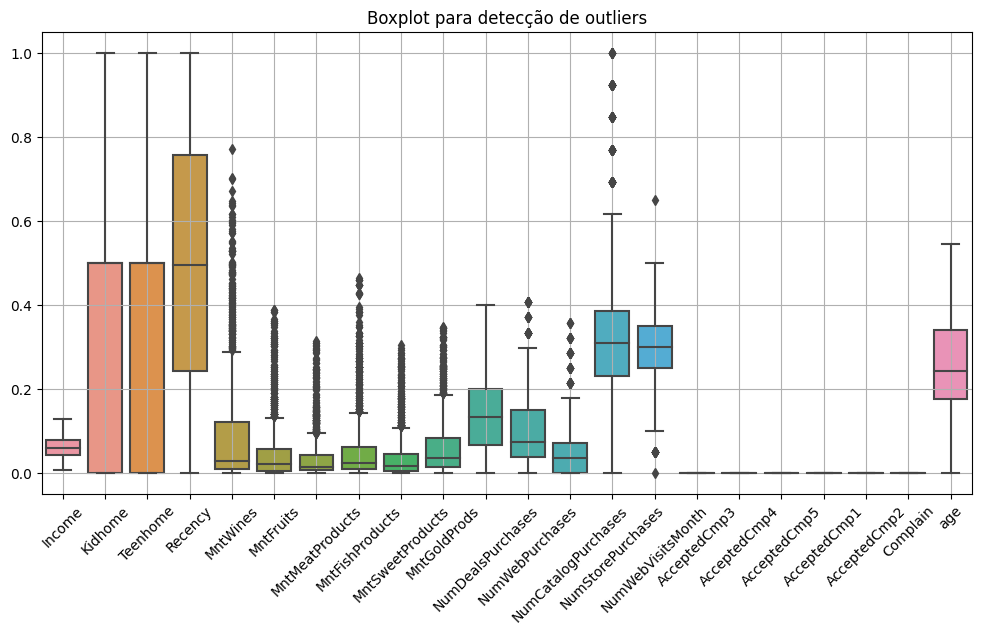

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title('Boxplot para detecção de outliers')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [35]:
data.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'age'],
      dtype='object')

In [36]:
data.drop(columns=['Teenhome', 'Kidhome', 'Recency', 'Complain', 'age', 'NumDealsPurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp2'], inplace=True)

In [37]:
df.drop(columns=['Teenhome', 'Kidhome', 'Recency', 'Complain', 'age', 'NumDealsPurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp2'], inplace=True)

In [38]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = "auto", random_state = 0)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

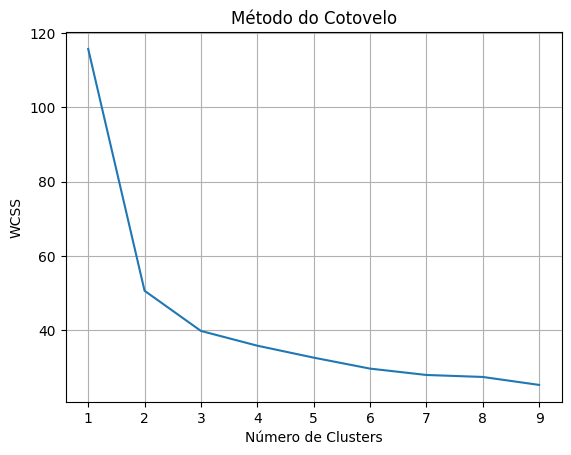

In [39]:
# Método do Cotovelo (Elbow Method) para determinar o número ideal de clusters.
plt.plot(range(1, 10), wcss)
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [40]:
for i in range(2, 10):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = "auto", random_state = 0)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)
    score = silhouette_score(data, kmeans.labels_)
    print(f"Silhouette Score {i} grupos: ",score)

Silhouette Score 2 grupos:  0.5993622666639772
Silhouette Score 3 grupos:  0.49147663032008937
Silhouette Score 4 grupos:  0.39907868414697717
Silhouette Score 5 grupos:  0.3967312888495187
Silhouette Score 6 grupos:  0.37885151852736837
Silhouette Score 7 grupos:  0.3749002635451503
Silhouette Score 8 grupos:  0.3206284113113812
Silhouette Score 9 grupos:  0.27203111578334194


In [41]:
k = 3

# Aplicando o KMeans com todas as colunas e o número ideal de clusters
kmeans = KMeans(n_clusters = k, init = 'k-means++', n_init = "auto", random_state = 0)
y_kmeans = kmeans.fit_predict(data)

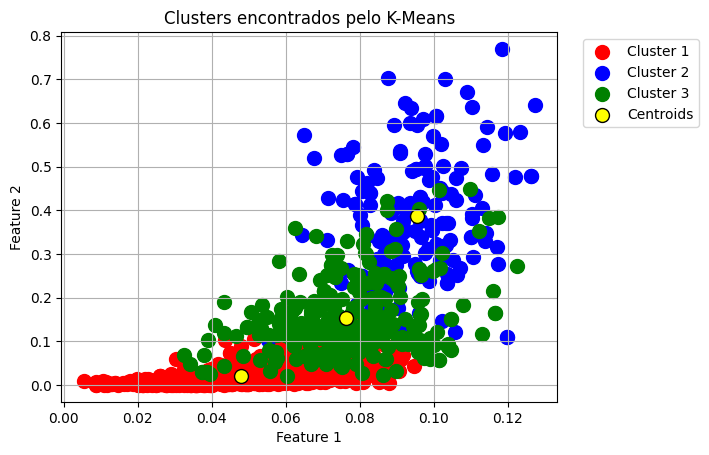

In [42]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', n_init = "auto", random_state = 0)
y_kmeans = kmeans.fit_predict(data)

colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'orange', 'purple', 'brown', 'pink', 'gray']

for i in range(k):
    plt.scatter(data.values[y_kmeans == i][:, 0], data.values[y_kmeans == i][:, 1],
                s=100, c=colors[i], label=f'Cluster {i+1}')

# Plotando os centróides
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=100, c='yellow', label='Centroids', edgecolor='black')

plt.title('Clusters encontrados pelo K-Means')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True)
plt.show()

In [43]:
ari_kmeans = adjusted_rand_score(df['Response'], kmeans.labels_)
print(f"Adjusted Rand Index (K-Means): {ari_kmeans}")

Adjusted Rand Index (K-Means): 0.0003852432475714076
